In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

# For preprocessing and modeling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# For Explainable AI 
import shap
import lime
import lime.lime_tabular
from PyALE import ale


import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data LOading and preprocessing

In [2]:

df = pd.read_csv('SINGAPORE Data 2.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
display(df.head())

# Visualize missing values
# msno.matrix(df)
# plt.title("Missing Data Overview")
# plt.show()

# Data cleaning and feature engineering
# The reading scores are stored in columns 'ACHIEV1' to 'ACHIEV5'
score_cols = ['ACHIEV1', 'ACHIEV2', 'ACHIEV3', 'ACHIEV4', 'ACHIEV5']

# Create a new column as the average reading score for each student.
df['READ_AVG'] = df[score_cols].mean(axis=1)



# Fill missing numeric values with the median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Exclude the target and reading score columns from predictors.
X = df.drop(columns=score_cols + ['READ_AVG'])
y = df['READ_AVG']

# Check for categorical and numeric features
# We will consider columns with fewer than 10 unique values as categorical.


cat_cols = [col for col in X.columns if X[col].nunique() < 10]
num_cols = [col for col in X.columns if col not in cat_cols]

print("Categorical features:", cat_cols)
print("Numeric features:", num_cols)

# One-hot encode categorical features
X_cat = pd.get_dummies(X[cat_cols], drop_first=True)

# Standardize numeric features
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(X[num_cols]), columns=num_cols)

# Concatenate processed numeric and categorical features
X_processed = pd.concat([X_num, X_cat], axis=1)

print("Processed data shape:", X_processed.shape)


Dataset shape: (6719, 31)


,IDBOOK,IDSUBJ,NTEACH,TCHWGT,JKREP,JKZONE,ACHIEV1,ACHIEV2,ACHIEV3,ACHIEV4,...,DISORD,LIKE,HOME,CONFID,COMPU,PRINCIP,SHORT,SUCCESS,DISCIP,HOURS
0,66,1,1,4.852941,1,40,499.44668,487.15735,486.73041,468.03947,...,999999.00000,12.98699,8.94299,999999.00000,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
1,18,1,1,4.852941,1,40,579.06932,650.65754,630.52949,644.08893,...,7.86603,8.04592,999999.00000,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
2,4,1,1,4.852941,1,40,604.30891,618.42213,591.35266,589.74334,...,10.57259,10.45984,11.74392,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
3,20,1,1,4.852941,1,40,541.98073,498.29331,490.45016,538.50204,...,10.21804,9.86291,9.29058,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
4,5,1,1,4.852941,1,40,531.15306,540.39422,548.59762,556.86243,...,5.92238,10.15574,9.70247,10.28978,458.0,2.0,9.4933,7.23401,9.92826,1108.33333


Categorical features: ['IDSUBJ', 'NTEACH', 'JKREP', 'EDUCA', 'PEDAG', 'ASSESS', 'PDTEACH', 'GEND']
Numeric features: ['IDBOOK', 'TCHWGT', 'JKZONE', 'TEACH', 'DIGIT', 'BELONG', 'BULLY', 'ENGAGE', 'DISORD', 'LIKE', 'HOME', 'CONFID', 'COMPU', 'PRINCIP', 'SHORT', 'SUCCESS', 'DISCIP', 'HOURS']
Processed data shape: (6719, 26)


## 2. Brief EDA

Descriptive statistics for the target:
count    6719.000000
mean      583.006084
std        82.662699
min       222.399708
25%       536.901319
50%       596.383582
75%       641.267624
max       777.493020
Name: READ_AVG, dtype: float64


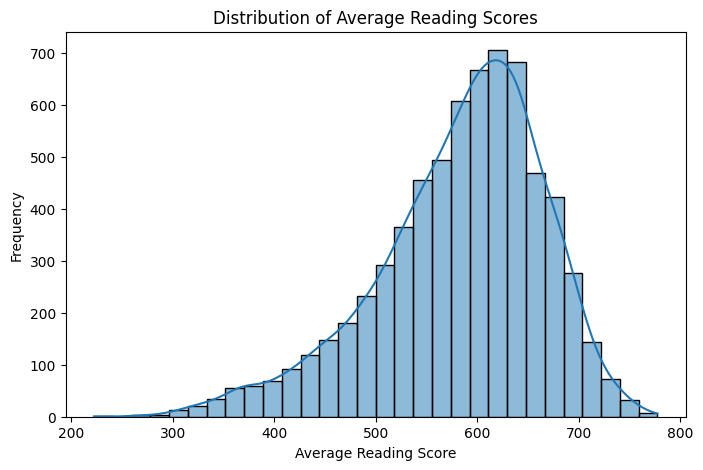

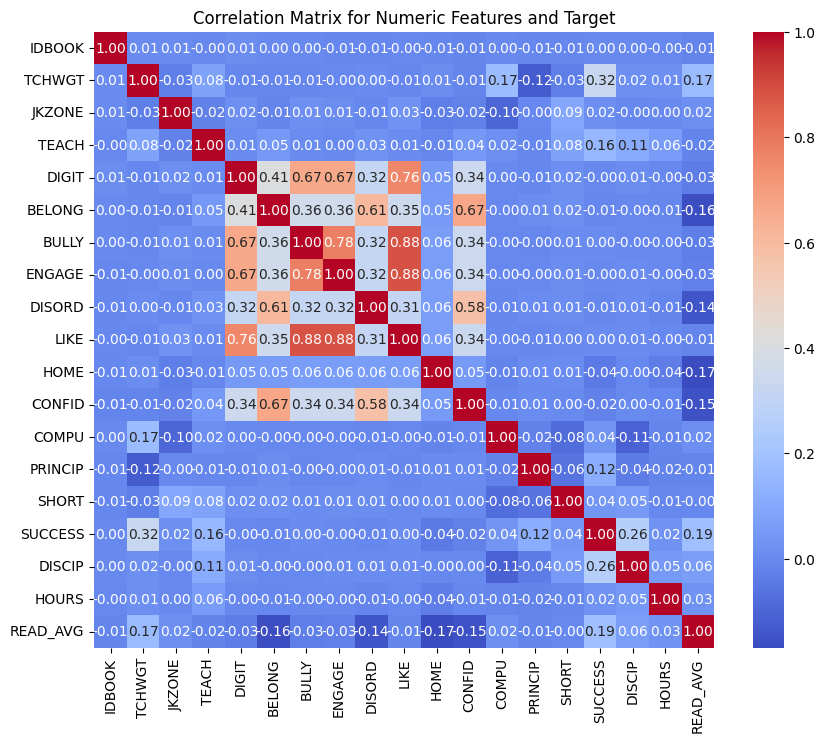

In [3]:

print("Descriptive statistics for the target:")
print(y.describe())

# Reading scores hitogram
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Average Reading Scores")
plt.xlabel("Average Reading Score")
plt.ylabel("Frequency")
plt.show()

#Corelation matrix for numeric features and the target
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['READ_AVG']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Numeric Features and Target")
plt.show()


# Scatter plot for home resources vs reading score
if 'ASBGHRL' in num_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df['ASBGHRL'], y=y)
    plt.title("Home Resources vs. Average Reading Score")
    plt.xlabel("Home Resources for Learning (ASBGHRL)")
    plt.ylabel("Average Reading Score")
    plt.show()


# Boxplot: reading score by gender

if 'ASBG01' in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=X['ASBG01'], y=y)
    plt.title("Reading Score by Gender")
    plt.xlabel("Gender (ASBG01)")
    plt.ylabel("Average Reading Score")
    plt.show()


## 3. Training regression models

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Import pipeline components
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Dictionary to store models and results
models = {}
results = {}

# Function to evaluate model performance
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f"{name} -- MSE: {mse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2%}")
    return mse, mae, mape

# 1. Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
mse_lr, mae_lr, mape_lr = evaluate_model("Linear Regression", lr_pipeline, X_test, y_test)
results['Linear Regression'] = {'MSE': mse_lr, 'MAE': mae_lr, 'MAPE': mape_lr}
models['Linear Regression'] = lr_pipeline

# 2. Ridge Regression Pipeline with GridSearch
ridge_pipeline = Pipeline([
    ('regressor', Ridge())
])
params_ridge = {'regressor__alpha': [0.1, 1, 10, 50, 100]}
grid_ridge = GridSearchCV(ridge_pipeline, params_ridge, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
print("Best Ridge alpha:", grid_ridge.best_params_)
mse_ridge, mae_ridge, mape_ridge = evaluate_model("Ridge Regression", best_ridge, X_test, y_test)
results['Ridge Regression'] = {'MSE': mse_ridge, 'MAE': mae_ridge, 'MAPE': mape_ridge}
models['Ridge Regression'] = best_ridge

# 3. Lasso Regression Pipeline with GridSearch
lasso_pipeline = Pipeline([
    ('regressor', Lasso(max_iter=10000))
])
params_lasso = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(lasso_pipeline, params_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_
print("Best Lasso alpha:", grid_lasso.best_params_)
mse_lasso, mae_lasso, mape_lasso = evaluate_model("Lasso Regression", best_lasso, X_test, y_test)
results['Lasso Regression'] = {'MSE': mse_lasso, 'MAE': mae_lasso, 'MAPE': mape_lasso}
models['Lasso Regression'] = best_lasso

# 4. Random Forest Pipeline with GridSearch
rf_pipeline = Pipeline([
    ('regressor', RandomForestRegressor(random_state=42))
])
params_rf = {
    'regressor__n_estimators': [100, 300],
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf_pipeline, params_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best RF params:", grid_rf.best_params_)
mse_rf, mae_rf, mape_rf = evaluate_model("Random Forest", best_rf, X_test, y_test)
results['Random Forest'] = {'MSE': mse_rf, 'MAE': mae_rf, 'MAPE': mape_rf}
models['Random Forest'] = best_rf

# 5. XGBoost Pipeline with GridSearch
xgb_pipeline = Pipeline([
    ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42))
])
params_xgb = {
    'regressor__n_estimators': [100, 300],
    'regressor__max_depth': [3, 6],
    'regressor__learning_rate': [0.1, 0.01]
}
grid_xgb = GridSearchCV(xgb_pipeline, params_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print("Best XGBoost params:", grid_xgb.best_params_)
mse_xgb, mae_xgb, mape_xgb = evaluate_model("XGBoost", best_xgb, X_test, y_test)
results['XGBoost'] = {'MSE': mse_xgb, 'MAE': mae_xgb, 'MAPE': mape_xgb}
models['XGBoost'] = best_xgb

# 6. Neural Network Pipeline with GridSearch
mlp_pipeline = Pipeline([
    ('regressor', MLPRegressor(random_state=42, max_iter=500))
])
params_mlp = {
    'regressor__hidden_layer_sizes': [(64,), (32, 32)],
    'regressor__alpha': [0.0001, 0.001]
}
grid_mlp = GridSearchCV(mlp_pipeline, params_mlp, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_mlp.fit(X_train, y_train)
best_mlp = grid_mlp.best_estimator_
print("Best MLP params:", grid_mlp.best_params_)
mse_mlp, mae_mlp, mape_mlp = evaluate_model("MLPRegressor", best_mlp, X_test, y_test)
results['MLPRegressor'] = {'MSE': mse_mlp, 'MAE': mae_mlp, 'MAPE': mape_mlp}
models['MLPRegressor'] = best_mlp

# Results summary
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
display(results_df)

# Find the best model
best_model_name = results_df['MSE'].idxmin()
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name} with MSE: {results_df.loc[best_model_name, 'MSE']:.2f}")

Training set shape: (5375, 26)
Test set shape: (1344, 26)
Linear Regression -- MSE: 334481459.16, MAE: 764.98, MAPE: 190.62%
Best Ridge alpha: {'regressor__alpha': 100}
Ridge Regression -- MSE: 5622.12, MAE: 59.71, MAPE: 10.98%
Best Lasso alpha: {'regressor__alpha': 0.1}
Lasso Regression -- MSE: 5586.14, MAE: 59.57, MAPE: 10.94%
Best RF params: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Random Forest -- MSE: 3656.36, MAE: 47.26, MAPE: 8.67%
Best XGBoost params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 300}
XGBoost -- MSE: 3211.53, MAE: 44.66, MAPE: 8.13%


/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reac

Best MLP params: {'regressor__alpha': 0.0001, 'regressor__hidden_layer_sizes': (64,)}
MLPRegressor -- MSE: 5521.50, MAE: 59.08, MAPE: 10.85%

Model Performance Comparison:


,MSE,MAE,MAPE
Linear Regression,3.344815e+08,764.979777,1.906198
Ridge Regression,5.622115e+03,59.705122,0.109779
Lasso Regression,5.586136e+03,59.565022,0.109417
Random Forest,3.656362e+03,47.255574,0.086717
XGBoost,3.211529e+03,44.664403,0.081250
MLPRegressor,5.521501e+03,59.079503,0.108500



Best model: XGBoost with MSE: 3211.53


## 4. Residual analysis and anomaly detection

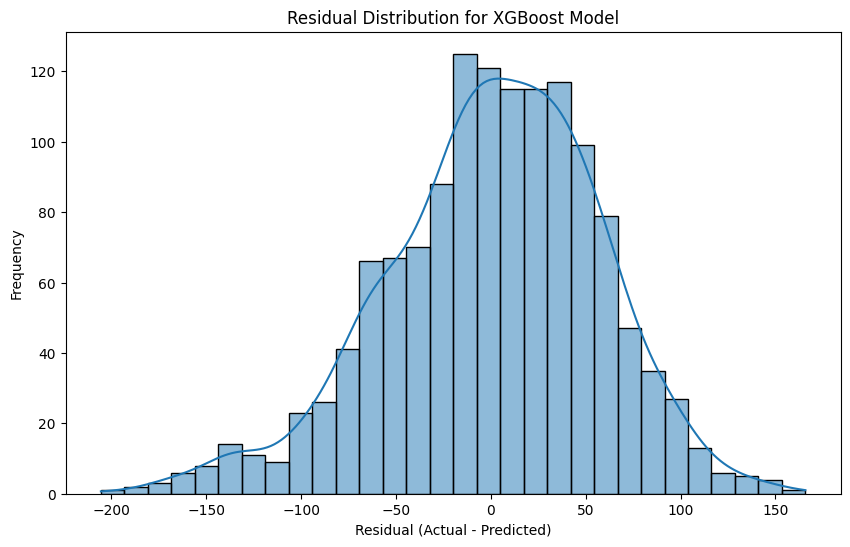

Number of anomalies detected: 68


In [7]:
# Residual Analysis for best model (XGBoost)
y_pred_best = best_xgb.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residual Distribution for XGBoost Model')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# Identify potential anomalies: large absolute residuals
anomaly_threshold = 2 * np.std(residuals)
anomalies = X_test[np.abs(residuals) > anomaly_threshold]
print("Number of anomalies detected:", anomalies.shape[0])


## 5. xAI analysis


SHAP values explain how each feature affects model predictions.

## Key Formula
The SHAP value for a feature $i$ is given by:

$$\phi_i = \sum_{S \subseteq N \backslash \{i\}} \frac{|S|!(|N|-|S|-1)!}{|N|!}[f(S \cup \{i\}) - f(S)]$$

Where:
- $S$ is a subset of features without feature $i$
- $f(S)$ is the model prediction using only features in $S$

## Interpretation
- A prediction equals: base value + sum of all SHAP values
- **Positive SHAP**: Feature pushes prediction higher
- **Negative SHAP**: Feature pushes prediction lower
- **Larger magnitude**: More important feature

SHAP values show both which features matter most overall and how they affect specific predictions.

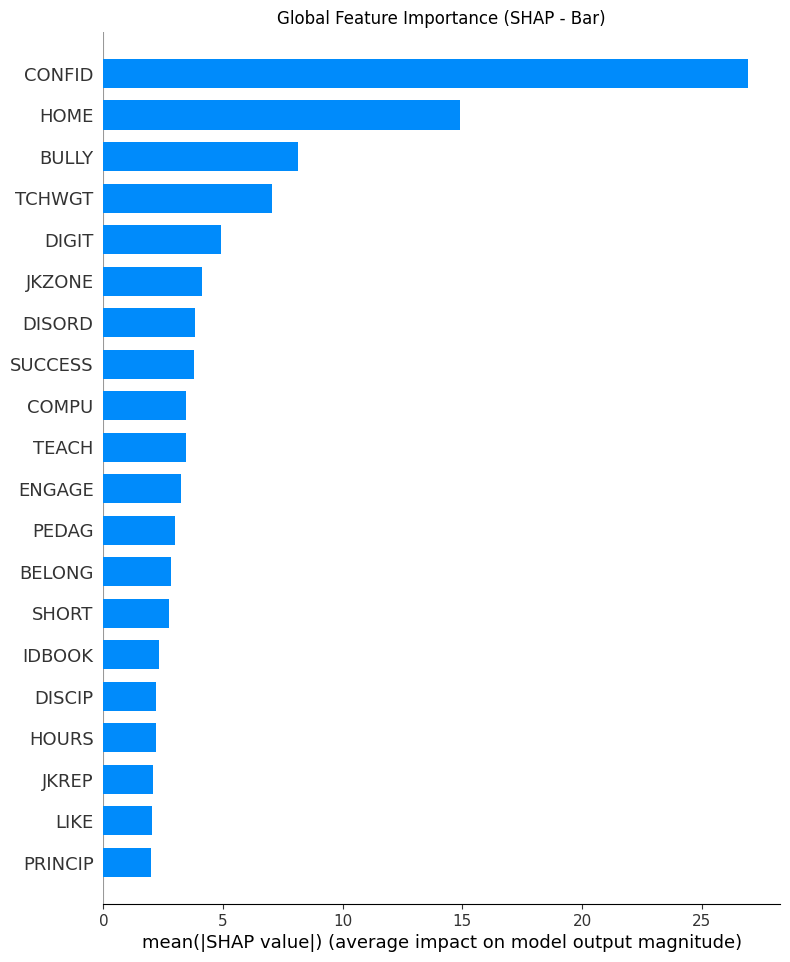

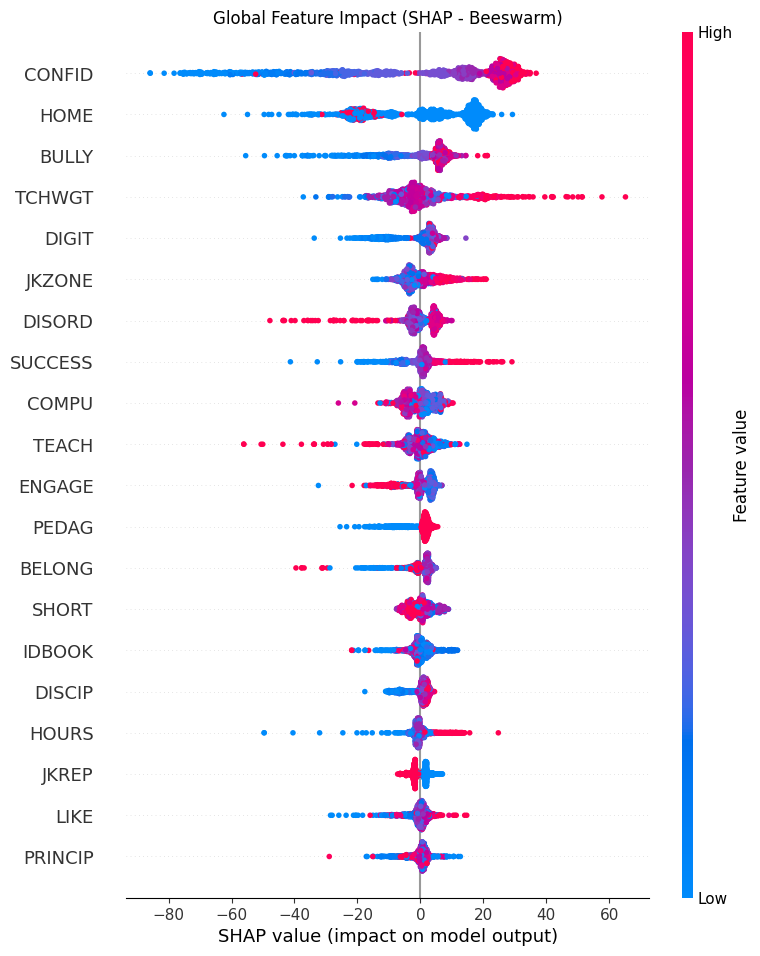

In [8]:
# SHAP Analysis for the best model (XGBoost)
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# SHAP Summary Plot (Bar plot for global feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP - Bar)")
plt.show()

# SHAP Summary Plot (Beeswarm plot for detailed impact)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Global Feature Impact (SHAP - Beeswarm)")
plt.show()



In [9]:
# ALE plot for a specific feature

# We create ALE plots to see the average effect of a feature.
# For example, for the feature 'ASBGHRL' (Home Resources), if present.
# if 'ASBGHRL' in X_num.columns:
#     ale_eff = ale(X_train, best_xgb.predict, feature=["ASBGHRL"], include_CI=False, bins=20)
#     ale.plot(ale_eff)
#     plt.title("ALE Plot for Home Resources (ASBGHRL)")
#     plt.show()


In [10]:
# LIME Explanation for a single instance
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)

# Choose one test instance to explain (for example, the first instance)
i = 0
exp = lime_explainer.explain_instance(X_test.iloc[i].values, best_xgb.predict, num_features=10)

# Display the LIME explanation in the notebook.
exp.show_in_notebook(show_table=True)
